# Session 9: Synthetic Data Generation and RAG Evaluation with LangSmith

In the following notebook we'll explore a use-case for RAGAS' synthetic testset generation workflow, and use it to evaluate and iterate on a RAG pipeline with LangSmith!

**Learning Objectives:**
- Understand Ragas' knowledge graph-based synthetic data generation workflow
- Generate synthetic test sets with different query synthesizer types
- Load synthetic data into LangSmith for evaluation
- Evaluate a RAG chain using LangSmith evaluators
- Iterate on RAG pipeline parameters and measure the impact

## Table of Contents:

- **Breakout Room #1:** Synthetic Data Generation with Ragas
  - Task 1: Dependencies and API Keys
  - Task 2: Data Preparation and Knowledge Graph Construction
  - Task 3: Generating Synthetic Test Data
  - Question #1 & Question #2
  - 🏗️ Activity #1: Custom Query Distribution

- **Breakout Room #2:** RAG Evaluation with LangSmith
  - Task 4: LangSmith Dataset Setup
  - Task 5: Building a Basic RAG Chain
  - Task 6: Evaluating with LangSmith
  - Task 7: Modifying the Pipeline and Re-Evaluating
  - Question #3 & Question #4
  - 🏗️ Activity #2: Analyze Evaluation Results

---
# 🤝 Breakout Room #1
## Synthetic Data Generation with Ragas

## Task 1: Dependencies and API Keys

We'll need to install a number of API keys and dependencies, since we'll be leveraging a number of great technologies for this pipeline!

1. OpenAI's endpoints to handle the Synthetic Data Generation
2. OpenAI's Endpoints for our RAG pipeline and LangSmith evaluation
3. QDrant as our vectorstore
4. LangSmith for our evaluation coordinator!

Let's install and provide all the required information below!

## Dependencies and API Keys:

### NLTK Import

To prevent errors that may occur based on OS - we'll import NLTK and download the needed packages to ensure correct handling of data.

In [1]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [2]:
import os
import getpass

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangChain API Key:")

LangChain API Key:··········


We'll also want to set a project name to make things easier for ourselves.

In [ ]:
from uuid import uuid4

os.environ["LANGCHAIN_PROJECT"] = f"AIM - SDG - {uuid4().hex[0:8]}"

OpenAI's API Key!

In [4]:
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key:")

OpenAI API Key:··········


## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data using two complementary guides — a Health & Wellness Guide covering exercise, nutrition, sleep, and stress management, and a Mental Health & Psychology Handbook covering mental health conditions, therapeutic approaches, resilience, and daily mental health practices. The topical overlap between documents helps RAGAS build rich cross-document relationships in the knowledge graph.

Next, let's load our data into a familiar LangChain format using the `TextLoader`.

In [6]:
!pip install -U --no-cache-dir langchain langchain-core langchain-community
!pip install requests==2.32.4
!pip install pypdf

from google.colab import drive
drive.mount('/content/drive')

from langchain_community.document_loaders import DirectoryLoader, TextLoader

""" loader = DirectoryLoader("data/", glob="*.txt", loader_cls=TextLoader)
docs = loader.load()
print(f"Loaded {len(docs)} documents: {[d.metadata['source'] for d in docs]}")"""

from langchain_community.document_loaders import DirectoryLoader, TextLoader


from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader

DATA_PATH = "/content/drive/My Drive/AIE9/09_Synthetic_Data_Generation_and_LangSmith/data"

loader = DirectoryLoader(
    DATA_PATH,
    glob="*.pdf",
    loader_cls=PyPDFLoader
)

docs = loader.load()

print(f"Loaded {len(docs)} documents")
print([d.metadata.get("source") for d in docs])

""" for f in os.listdir(DATA_PATH):
    print(f, mimetypes.guess_type(f)) """



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 184.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
Using cached requests-2.32.4-py3-none-any.whl (64 kB)
  Attempting uninstall: requests
    Found existing installation: requests 2.32.5
    Uninstalling requests-2.32.5:
      Successfully uninstalled requests-2.32.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-community 0.4.1 requires requests<3.0.0,>=2.32.5, but you have requests 2.32.4 which is incompatible.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 22 documents
['/content/drive/My Drive/AIE9/09_Synthetic_Data_Generation_and_LangSmith/data/HealthWellnessGuide.pdf', '/content/drive/My Drive/AIE9/09_Synthetic_Data_Generation_and_LangSmith/data/HealthWellnessGuide.pdf', '/content/drive/My Drive/AIE9/09_Synthetic_Data_Generation_and_LangSmith/data/HealthWellnessGuide.pdf', '/content/drive/My Drive/AIE9/09_Synthetic_Data_Generation_and_LangSmith/data/HealthWellnessGuide.pdf', '/content/drive/My Drive/AIE9/09_Synthetic_Data_Generation_and_LangSmith/data/HealthWellnessGuide.pdf', '/content/drive/My Drive/AIE9/09_Synthetic_Data_Generation_and_LangSmith/data/HealthWellnessGuide.pdf', '/content/drive/My Drive/AIE9/09_Synthetic_Data_Generation_and_LangSmith/data/HealthWellnessGuide.pdf', '/content/drive/My Drive/AIE9/09_Synthetic_Data_Generation_and_LangSmith/data/HealthWellnessGuide.pdf', '/content/drive/My

' for f in os.listdir(DATA_PATH):\n    print(f, mimetypes.guess_type(f)) '

### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Unrolled SDG

In [7]:
%pip install -U ragas
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.4/177.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.8/358.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: jiter
    Found existing installation: jiter 0.13.0
    Uninstalling jiter-0.13.0:
      Successfully uninstalled jiter-0.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
/tmp/ipython-input-1910482404.py:6: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-nano"))
/tmp/ipython-input-1910482404.py:7: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model

Next, we're going to instantiate our Knowledge Graph.

This graph will contain N number of nodes that have M number of relationships. These nodes and relationships (AKA "edges") will define our knowledge graph and be used later to construct relevant questions and responses.

In [9]:
from ragas.testset.graph import KnowledgeGraph

kg = KnowledgeGraph()
kg

KnowledgeGraph(nodes: 0, relationships: 0)

The first step we're going to take is to simply insert each of our full documents into the graph. This will provide a base that we can apply transformations to.

In [10]:
from ragas.testset.graph import Node, NodeType

for doc in docs:
    kg.nodes.append(
        Node(
            type=NodeType.DOCUMENT,
            properties={"page_content": doc.page_content, "document_metadata": doc.metadata}
        )
    )
kg

KnowledgeGraph(nodes: 22, relationships: 0)

Now, we'll apply the *default* transformations to our knowledge graph. This will take the nodes currently on the graph and transform them based on a set of [default transformations](https://docs.ragas.io/en/latest/references/transforms/#ragas.testset.transforms.default_transforms).

These default transformations are dependent on the corpus length, in our case:

- Producing Summaries -> produces summaries of the documents
- Extracting Headlines -> finding the overall headline for the document
- Theme Extractor -> extracts broad themes about the documents

It then uses cosine-similarity and heuristics between the embeddings of the above transformations to construct relationships between the nodes.

In [11]:
!pip install rapidfuzz
from ragas.testset.transforms import default_transforms, apply_transforms

transformer_llm = generator_llm
embedding_model = generator_embeddings

default_transforms = default_transforms(documents=docs, llm=transformer_llm, embedding_model=embedding_model)
apply_transforms(kg, default_transforms)
kg

Applying SummaryExtractor:   0%|          | 0/22 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/22 [00:00<?, ?it/s]

Applying EmbeddingExtractor:   0%|          | 0/22 [00:00<?, ?it/s]

Applying ThemesExtractor:   0%|          | 0/22 [00:00<?, ?it/s]

Applying NERExtractor:   0%|          | 0/22 [00:00<?, ?it/s]

Applying CosineSimilarityBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Applying OverlapScoreBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

KnowledgeGraph(nodes: 22, relationships: 262)

We can save and load our knowledge graphs as follows.

In [13]:
kg.save("usecase_data_kg.json")
usecase_data_kg = KnowledgeGraph.load("usecase_data_kg.json")
usecase_data_kg

KnowledgeGraph(nodes: 22, relationships: 262)

Using our knowledge graph, we can construct a "test set generator" - which will allow us to create queries.

In [15]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=embedding_model, knowledge_graph=usecase_data_kg)

However, we'd like to be able to define the kinds of queries we're generating - which is made simple by Ragas having pre-created a number of different "QuerySynthesizer"s.

Each of these Synthetsizers is going to tackle a separate kind of query which will be generated from a scenario and a persona.

In essence, Ragas will use an LLM to generate a persona of someone who would interact with the data - and then use a scenario to construct a question from that data and persona.

In [22]:
from ragas.testset.synthesizers import default_query_distribution, SingleHopSpecificQuerySynthesizer, MultiHopAbstractQuerySynthesizer, MultiHopSpecificQuerySynthesizer

query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.5),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.25),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.25),
]

## ❓ Question #1:

What are the three types of query synthesizers doing? Describe each one in simple terms.

##### Answer:
Single-hop synthesizer generates simple questions that can be answered using information from one document or one concept node. These questions test basic retrieval and factual accuracy.

Multi-hop synthesizer generates questions that require combining information from multiple related nodes or documents. These test whether the system can retrieve and reason across multiple pieces of context.

Abstract (or reasoning) synthesizer generates higher-level questions that require summarization, explanation, or conceptual reasoning rather than direct fact lookup. These test whether the system truly understands the content instead of just retrieving text.

Finally, we can use our `TestSetGenerator` to generate our testset!

In [ ]:
testset = generator.generate(testset_size=10, query_distribution=query_distribution)
testset.to_pandas()

### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [20]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying SummaryExtractor:   0%|          | 0/22 [00:00<?, ?it/s]

Applying CustomNodeFilter:   0%|          | 0/22 [00:00<?, ?it/s]

Applying EmbeddingExtractor:   0%|          | 0/22 [00:00<?, ?it/s]

Applying ThemesExtractor:   0%|          | 0/22 [00:00<?, ?it/s]

Applying NERExtractor:   0%|          | 0/22 [00:00<?, ?it/s]

Applying CosineSimilarityBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Applying OverlapScoreBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

In [21]:
dataset.to_pandas()

,user_input,reference_contexts,reference,persona_name,query_style,query_length,synthesizer_name
0,What are some ways to improve your overall hea...,[The Personal Wellness Guide \nA Comprehensive...,The context emphasizes that exercise is one of...,Mental Health and Wellness Educator,WEB_SEARCH_LIKE,SHORT,single_hop_specific_query_synthesizer
1,Why is Sunday important for rest?,"[5 seconds, repeat 10 times. \n \nChapter 3: B...","In the beginner weekly schedule, Sunday is des...",Mental Health Advocate and Wellness Coach,MISSPELLED,SHORT,single_hop_specific_query_synthesizer
2,What are the symtoms of dehydration?,[Weekly Meal Planning Steps: \n1. Review your ...,Signs of dehydration include dark yellow urine...,Mental Health and Wellness Educator,MISSPELLED,SHORT,single_hop_specific_query_synthesizer
3,How can I improve my slep to get better rest?,[Adults typically need 7-9 hours of sleep per ...,Adults typically need 7-9 hours of sleep per n...,Mental Health and Wellness Advocate,MISSPELLED,MEDIUM,single_hop_specific_query_synthesizer
4,How does having a healthy breakfast relate to ...,[<1-hop>\n\n- Drink a glass of water immediate...,Having a healthy breakfast is part of a mornin...,NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
5,How can building positive routines help improv...,[<1-hop>\n\nMindfulness is the practice of bei...,"Building positive routines, such as practicing...",NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
6,How do exercise recommendations for mental hea...,[<1-hop>\n\nTypes of therapeutic journaling: \...,"Exercise recommendations for mental health, su...",NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
7,How exercise helps mental health at different ...,[<1-hop>\n\nTypes of therapeutic journaling: \...,Exercise improves mental health by releasing m...,NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
8,What chapter talk about evening routines and h...,[<1-hop>\n\n- Drink a glass of water immediate...,Chapter 15 discusses evening wind-down routine...,NaN,NaN,NaN,multi_hop_specific_query_synthesizer
9,How does Chapter 15's evening wind-down routin...,[<1-hop>\n\n- Drink a glass of water immediate...,Chapter 15 emphasizes establishing a consisten...,NaN,NaN,NaN,multi_hop_specific_query_synthesizer


## ❓ Question #2:

Ragas offers both an "unrolled" (manual) approach and an "abstracted" (automatic) approach to synthetic data generation. What are the trade-offs between these two approaches? When would you choose one over the other?

##### Answer:
The unrolled approach trades speed for control and transparency, while the abstracted approach trades control for ease of use and faster iteration.Choose unrolled for control and depth; choose abstracted for speed and simplicity.

---
## 🏗️ Activity #1: Custom Query Distribution

Modify the `query_distribution` to experiment with different ratios of query types.

### Requirements:
1. Create a custom query distribution with different weights than the default
2. Generate a new test set using your custom distribution
3. Compare the types of questions generated with the default distribution
4. Explain why you chose the weights you did

In [44]:
### YOUR CODE HERE ###

# Define a custom query distribution with different weights
from ragas.testset.synthesizers import default_query_distribution, SingleHopSpecificQuerySynthesizer, MultiHopAbstractQuerySynthesizer, MultiHopSpecificQuerySynthesizer

query_distribution = [
        (SingleHopSpecificQuerySynthesizer(llm=generator_llm), 0.5),
        (MultiHopAbstractQuerySynthesizer(llm=generator_llm), 0.25),
        (MultiHopSpecificQuerySynthesizer(llm=generator_llm), 0.25),
]
# I'm assuming my bot to give simple information.
# Generate a new test set and compare with the default
testset = generator.generate(testset_size=10, query_distribution=query_distribution)
testset.to_pandas()




Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/11 [00:00<?, ?it/s]

,user_input,reference_contexts,reference,persona_name,query_style,query_length,synthesizer_name
0,What is a Personal Wellness Guide do for health?,[The Personal Wellness Guide \nA Comprehensive...,The Personal Wellness Guide is a comprehensive...,Mental Health and Wellness Educator,POOR_GRAMMAR,MEDIUM,single_hop_specific_query_synthesizer
1,What are the main topics covered in Chapter 4 ...,"[5 seconds, repeat 10 times. \n \nChapter 3: B...",Chapter 4: Fundamentals of Healthy Eating cove...,Mental Health Advocate and Wellness Coach,WEB_SEARCH_LIKE,MEDIUM,single_hop_specific_query_synthesizer
2,What is a Sample Day of Balanced Eating?,[Weekly Meal Planning Steps: \n1. Review your ...,A Sample Day of Balanced Eating includes break...,Mental Health Advocate and Wellness Coach,WEB_SEARCH_LIKE,SHORT,single_hop_specific_query_synthesizer
3,How does valerian root help with sleep and wha...,[Adults typically need 7-9 hours of sleep per ...,Valerian root is mentioned as a natural remedy...,Mental Health and Wellness Advocate,POOR_GRAMMAR,LONG,single_hop_specific_query_synthesizer
4,What is covered in Chapter 12?,[PART 4: STRESS MANAGEMENT AND MENTAL WELLNESS...,Chapter 12 discusses mindfulness and meditatio...,Mental Health and Wellness Advocate,WEB_SEARCH_LIKE,SHORT,single_hop_specific_query_synthesizer
5,How does reviewing goals and prioritization in...,[<1-hop>\n\n- Drink a glass of water immediate...,"Reviewing goals and priorities for the day, as...",NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
6,How can practicin mindfulness meditation techn...,[<1-hop>\n\nMindfulness is the practice of bei...,"Practicing mindfulness meditation techniques, ...",NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
7,How do physiolog effects of exercis help bounc...,[<1-hop>\n\nTypes of therapeutic journaling: \...,"The physiological effects of exercise, such as...",NaN,NaN,NaN,multi_hop_abstract_query_synthesizer
8,how CBT help sleep and mental health like in c...,[<1-hop>\n\n- People who exercise regularly re...,"Cognitive Behavioral Therapy, especially CBT-I...",NaN,NaN,NaN,multi_hop_specific_query_synthesizer
9,Wht are the evening routine tips from Chaper 1...,[<1-hop>\n\n- Drink a glass of water immediate...,"According to Chapter 15, effective evening rou...",NaN,NaN,NaN,multi_hop_specific_query_synthesizer


We'll need to provide our LangSmith API key, and set tracing to "true".

---
# 🤝 Breakout Room #2
## RAG Evaluation with LangSmith

## Task 4: LangSmith Dataset

Now we can move on to creating a dataset for LangSmith!

First, we'll need to create a dataset on LangSmith using the `Client`!

We'll name our Dataset to make it easy to work with later.

In [26]:
from langsmith import Client
import uuid

client = Client()

dataset_name = f"Use Case Synthetic Data - AIE9 - {uuid.uuid4()}"

langsmith_dataset = client.create_dataset(
    dataset_name=dataset_name,
    description="Synthetic Data for Use Cases"
)

We'll iterate through the RAGAS created dataframe - and add each example to our created dataset!

> NOTE: We need to conform the outputs to the expected format - which in this case is: `question` and `answer`.

In [27]:
for data_row in dataset.to_pandas().iterrows():
  client.create_example(
      inputs={
          "question": data_row[1]["user_input"]
      },
      outputs={
          "answer": data_row[1]["reference"]
      },
      metadata={
          "context": data_row[1]["reference_contexts"]
      },
      dataset_id=langsmith_dataset.id
  )

## Basic RAG Chain

Time for some RAG!


In [28]:
rag_documents = docs

To keep things simple, we'll just use LangChain's recursive character text splitter!


In [29]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

We'll create our vectorstore using OpenAI's [`text-embedding-3-small`](https://platform.openai.com/docs/guides/embeddings/embedding-models) embedding model.

In [30]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

As usual, we will power our RAG application with Qdrant!

In [33]:
!pip install langchain-qdrant
from langchain_qdrant import QdrantVectorStore

vectorstore = QdrantVectorStore.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="use_case_rag"
)

In [34]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 10})

To get the "A" in RAG, we'll provide a prompt.

In [35]:
from langchain_core.prompts import ChatPromptTemplate

RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Context: {context}
Question: {question}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

In [36]:
from langchain_openai import ChatOpenAI
print("ChatOpenAI import OK")

llm = ChatOpenAI(model="gpt-4.1-mini")
print(llm.invoke("Hello"))


ChatOpenAI import OK
content='Hello! How can I assist you today?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_a391f2cee0', 'id': 'chatcmpl-D9MTME2u0QyFVyrlMD9X976jRvMdI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019c5f33-10ad-7821-b9f1-97a93d0843ee-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}


As is usual: We'll be using `gpt-4.1-mini` for our RAG!

In [ ]:
!pip install -U --no-cache-dir \
  langchain-core>=0.3.20 \
  langchain-openai>=0.2.5 \
  langchain-community>=0.3.20

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini")

Finally, we can set-up our RAG LCEL chain!

In [37]:
from operator import itemgetter
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser

rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | rag_prompt | llm | StrOutputParser()
)

In [38]:
rag_chain.invoke({"question" : "What are some recommended exercises for lower back pain?"})

'Recommended exercises for lower back pain include:\n\n- Cat-Cow Stretch: Start on hands and knees, alternate between arching your back up (cat) and letting it sag down (cow). Do 10-15 repetitions.  \n- Bird Dog: From hands and knees, extend opposite arm and leg while keeping your core engaged. Hold for 5 seconds, then switch sides. Do 10 repetitions per side.  \n- Partial Crunches: Lie on your back with knees bent, cross arms over chest, tighten stomach muscles and raise shoulders off floor. Hold briefly, then lower. Do 8-12 repetitions.  \n- Knee-to-Chest Stretch: Lie on your back, pull one knee toward your chest while keeping the other foot flat. Hold for 15-30 seconds, then switch legs.  \n- Pelvic Tilts: Lie on your back with knees bent, flatten your back against the floor by tightening abs and tilting pelvis up slightly. Hold for 10 seconds, repeat 8-12 times.'

## LangSmith Evaluation Set-up

We'll use OpenAI's GPT-4.1 as our evaluation LLM for our base Evaluators.

In [39]:
eval_llm = ChatOpenAI(model="gpt-4.1")

We'll be using a number of evaluators - from LangSmith provided evaluators, to a few custom evaluators!

In [42]:
!pip install openevals
from openevals.llm import create_llm_as_judge
from langsmith.evaluation import evaluate

# 1. QA Correctness (replaces LangChainStringEvaluator("qa"))
qa_evaluator = create_llm_as_judge(
    prompt="You are evaluating a QA system. Given the input, assess whether the prediction is correct.\n\nInput: {inputs}\nPrediction: {outputs}\nReference answer: {reference_outputs}\n\nIs the prediction correct? Return 1 if correct, 0 if incorrect.",
    feedback_key="qa",
    model="openai:gpt-4o" ,  # pass your LangChain chat model directly
)

# 2. Labeled Helpfulness (replaces LangChainStringEvaluator("labeled_criteria"))
labeled_helpfulness_evaluator = create_llm_as_judge(
    prompt=(
        "You are assessing a submission based on the following criterion:\n\n"
        "helpfulness: Is this submission helpful to the user, "
        "taking into account the correct reference answer?\n\n"
        "Input: {inputs}\n"
        "Submission: {outputs}\n"
        "Reference answer: {reference_outputs}\n\n"
        "Does the submission meet the criterion? Return 1 if yes, 0 if no."
    ),
    feedback_key="helpfulness",
    model="openai:gpt-4o" ,
)

# 3. Dopeness (replaces LangChainStringEvaluator("criteria"))
dopeness_evaluator = create_llm_as_judge(
    prompt=(
        "You are assessing a submission based on the following criterion:\n\n"
        "dopeness: Is this response dope, lit, cool, or is it just a generic response?\n\n"
        "Input: {inputs}\n"
        "Submission: {outputs}\n\n"
        "Does the submission meet the criterion? Return 1 if yes, 0 if no."
    ),
    feedback_key="dopeness",
    model="openai:gpt-4o" ,
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 4.1 MB/s eta 0:00:00


> **Describe what each evaluator is evaluating:**
>
> - `qa_evaluator`:
> - `labeled_helpfulness_evaluator`:
> - `dopeness_evaluator`:

## LangSmith Evaluation

In [43]:
evaluate(
    rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "default_chain_init"},
)

View the evaluation results for experiment: 'back-learning-94' at:
https://smith.langchain.com/o/4d03c1f3-77bb-43a3-8d8f-78229da68f66/datasets/d1a17abc-a723-4c5f-bc96-7efc8aac82f0/compare?selectedSessions=8c75a55f-8f03-4a66-bf78-39c932b680f1




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.qa,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,Chapter 12 sleep bad mental health how sleep c...,Chapter 12 explains that sleep and mental heal...,None,Chapter 12 explains that poor sleep can trigge...,True,True,False,2.551404,b6472c2a-56a8-448a-a14b-8ecdc3e02836,019c5f37-7415-71f2-bf3d-bbc346d5ce5c
1,How does Chapter 10 contribute to understandin...,Chapter 10 provides a foundational understandi...,None,Chapter 10 provides an understanding of stress...,True,True,False,1.718239,34b67152-d000-4f2c-a3cd-6f3ff21175da,019c5f37-a2b9-7a52-a211-8ecc3d17e268
2,How does Chapter 15's evening wind-down routin...,Chapter 15's evening wind-down routine support...,None,Chapter 15 emphasizes establishing a consisten...,True,True,True,2.472338,1612315f-7e87-4348-99da-67dc3e4af66d,019c5f37-c560-75b3-8a67-2679326db659
3,What chapter talk about evening routines and h...,Chapter 15 discusses evening wind-down routine...,None,Chapter 15 discusses evening wind-down routine...,True,True,False,2.310728,d891cccf-a433-4a42-b1bb-535ba643cacf,019c5f37-ec57-7cf0-9803-6d20b6c48c23
4,How exercise helps mental health at different ...,Exercise helps mental health at different life...,None,Exercise improves mental health by releasing m...,True,True,True,2.932055,4ce96b9b-442a-4fe4-8e32-e774e132569c,019c5f38-1c51-7b11-ae9b-a29b65dfa19f
5,How do exercise recommendations for mental hea...,The exercise recommendations for mental health...,None,"Exercise recommendations for mental health, su...",True,True,False,1.394898,676d715a-91aa-46b1-a8f9-95948efa8bf1,019c5f38-3fad-7673-94d3-3c66f6751d68
6,How can building positive routines help improv...,Building positive routines helps improve emoti...,None,"Building positive routines, such as practicing...",True,True,True,2.019948,d774bc05-49e2-463a-989c-8ae5a6456e00,019c5f38-5ea9-70f3-b20d-0681170d680d
7,How does having a healthy breakfast relate to ...,Having a healthy breakfast is part of a sample...,None,Having a healthy breakfast is part of a mornin...,True,True,False,2.241825,d62a172a-de0f-4a99-b71b-3d8950a47830,019c5f38-831f-7ca2-b6a5-f66549d8be48
8,How can I improve my slep to get better rest?,"To improve your sleep and get better rest, fol...",None,Adults typically need 7-9 hours of sleep per n...,True,True,False,3.189806,8c1e6d1c-3032-455f-a40e-898c98f740ee,019c5f38-a674-7f70-9e2e-e938ebd4121c
9,What are the symtoms of dehydration?,Signs of dehydration include: \n- Dark yellow...,None,Signs of dehydration include dark yellow urine...,True,True,False,1.123868,ecc20fa7-125c-4572-8b07-adfac8446790,019c5f38-d60c-7ab2-9b41-f019eeee98af


## Dope-ifying Our Application

We'll be making a few changes to our RAG chain to increase its performance on our SDG evaluation test dataset!

- Include a "dope" prompt augmentation
- Use larger chunks
- Improve the retriever model to: `text-embedding-3-large`

Let's see how this changes our evaluation!

In [45]:
DOPENESS_RAG_PROMPT = """\
Given a provided context and question, you must answer the question based only on context.

If you cannot answer the question based on the context - you must say "I don't know".

Make your answer rad, ensure high levels of dopeness. Do not be generic, or give generic responses.

Context: {context}
Question: {question}
"""

dopeness_rag_prompt = ChatPromptTemplate.from_template(DOPENESS_RAG_PROMPT)

In [46]:
rag_documents = docs

In [47]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000,
    chunk_overlap = 50
)

rag_documents = text_splitter.split_documents(rag_documents)

## ❓ Question #3:

Why would modifying our chunk size modify the performance of our application?

##### Answer:
Small chunks: May break apart related concepts

Large chunks: May mix multiple topics together

Optimal chunks: Preserve complete thoughts/paragraphs

In [48]:
# Because the right chunk size balances context relevance and noise, letting the model retrieve just enough useful information without wasting tokens or missing key details.


from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

## ❓ Question #4:

Why would modifying our embedding model modify the performance of our application?

##### Answer:
Different embedding models have different levels of language understanding:

In [49]:
from langchain_qdrant import QdrantVectorStore

vectorstore = QdrantVectorStore.from_documents(
    documents=rag_documents,
    embedding=embeddings,
    location=":memory:",
    collection_name="Use Case RAG Docs"
)

In [50]:
retriever = vectorstore.as_retriever()

Setting up our new and improved DOPE RAG CHAIN.

In [51]:
dopeness_rag_chain = (
    {"context": itemgetter("question") | retriever, "question": itemgetter("question")}
    | dopeness_rag_prompt | llm | StrOutputParser()
)

Let's test it on the same output that we saw before.

In [52]:
dopeness_rag_chain.invoke({"question" : "How can I improve my sleep quality?"})

'Alright, here’s how to LEVEL UP your sleep game and surf those dream waves like a true sleep ninja:\n\n1. **Lock down your sleep schedule** —Go full consistency mode, even on weekends. Your body vibes hard on routine.\n\n2. **Rock a chill bedtime ritual** —Think slow jams for your soul: reading, gentle stretching, or a warm bath. Kiss stress goodbye.\n\n3. **Cool, dark, and quiet is the vibe** —Set your room to a comfy 65-68°F (18-20°C), blackout those windows like a stealth pro, and bring in white noise or earplugs if needed.\n\n4. **Cut the caffeine after 2 PM** —No jangly jitters before dreamland gate.\n\n5. **Exercise, but don’t sprint to bed** —Hit those gains during the day, but let your body wind down before sleep.\n\n6. **Ditch heavy meals and alcohol close to bedtime** —Keep your stomach light and stress-free.\n\n7. **Say no to screens 1-2 hours before you crash** —Blue light blockers? Nah, just unplug and let your brain prep for REM mode.\n\n8. **Invest in a cozy mattress an

Finally, we can evaluate the new chain on the same test set!

In [53]:
evaluate(
    dopeness_rag_chain.invoke,
    data=dataset_name,
    evaluators=[
        qa_evaluator,
        labeled_helpfulness_evaluator,
        dopeness_evaluator
    ],
    metadata={"revision_id": "dopeness_rag_chain"},
)

View the evaluation results for experiment: 'flowery-book-33' at:
https://smith.langchain.com/o/4d03c1f3-77bb-43a3-8d8f-78229da68f66/datasets/d1a17abc-a723-4c5f-bc96-7efc8aac82f0/compare?selectedSessions=89004680-63cf-44ac-a935-ff74d358c1b6




0it [00:00, ?it/s]

,inputs.question,outputs.output,error,reference.answer,feedback.qa,feedback.helpfulness,feedback.dopeness,execution_time,example_id,id
0,Chapter 12 sleep bad mental health how sleep c...,"Yo, Chapter 12 drops some serious knowledge bo...",None,Chapter 12 explains that poor sleep can trigge...,True,True,True,2.683295,b6472c2a-56a8-448a-a14b-8ecdc3e02836,019c5f40-d89e-7f52-9b0a-71fb77e36324
1,How does Chapter 10 contribute to understandin...,Chapter 10 drops the ultimate truth bomb on st...,None,Chapter 10 provides an understanding of stress...,True,True,True,2.559128,34b67152-d000-4f2c-a3cd-6f3ff21175da,019c5f41-0b1b-7043-83e4-1adfaba1a7f2
2,How does Chapter 15's evening wind-down routin...,"Alright, let’s connect the cosmic dots between...",None,Chapter 15 emphasizes establishing a consisten...,True,True,True,3.263907,1612315f-7e87-4348-99da-67dc3e4af66d,019c5f41-4311-7721-8c27-b8238773dcb5
3,What chapter talk about evening routines and h...,"Yo, here’s the lowdown straight from the Healt...",None,Chapter 15 discusses evening wind-down routine...,True,True,True,4.492981,d891cccf-a433-4a42-b1bb-535ba643cacf,019c5f41-6f7a-7d10-a365-c5e57a40a33e
4,How exercise helps mental health at different ...,"Yo, let’s break down the mind-body magic of ex...",None,Exercise improves mental health by releasing m...,True,True,True,6.425635,4ce96b9b-442a-4fe4-8e32-e774e132569c,019c5f41-a53d-7e13-ba75-8b924b1b4eee
5,How do exercise recommendations for mental hea...,"Oh snap, let’s break down how those exercise r...",None,"Exercise recommendations for mental health, su...",True,True,True,4.162455,676d715a-91aa-46b1-a8f9-95948efa8bf1,019c5f41-df02-7423-b59a-45e5eed81714
6,How can building positive routines help improv...,"Alright, let’s crank up the vibes on this one!...",None,"Building positive routines, such as practicing...",True,True,True,3.726684,d774bc05-49e2-463a-989c-8ae5a6456e00,019c5f42-19f4-7571-a444-b50af999410e
7,How does having a healthy breakfast relate to ...,"Alright, buckle up for this wellness wisdom bl...",None,Having a healthy breakfast is part of a mornin...,True,True,True,2.740666,d62a172a-de0f-4a99-b71b-3d8950a47830,019c5f42-43b6-7853-aa71-47eca9ab4d58
8,How can I improve my slep to get better rest?,"Yo, if you wanna level up your sleep game and ...",None,Adults typically need 7-9 hours of sleep per n...,True,True,True,4.679990,8c1e6d1c-3032-455f-a40e-898c98f740ee,019c5f42-753c-78a1-8ed9-bf32b2907694
9,What are the symtoms of dehydration?,"Yo, here’s the lowdown on dehydration symptoms...",None,Signs of dehydration include dark yellow urine...,True,True,True,1.538632,ecc20fa7-125c-4572-8b07-adfac8446790,019c5f42-b272-7812-8a22-47bc4c29560c


---
## 🏗️ Activity #2: Analyze Evaluation Results

Provide a screenshot of the difference between the two chains in LangSmith, and explain why you believe certain metrics changed in certain ways.

##### Answer:
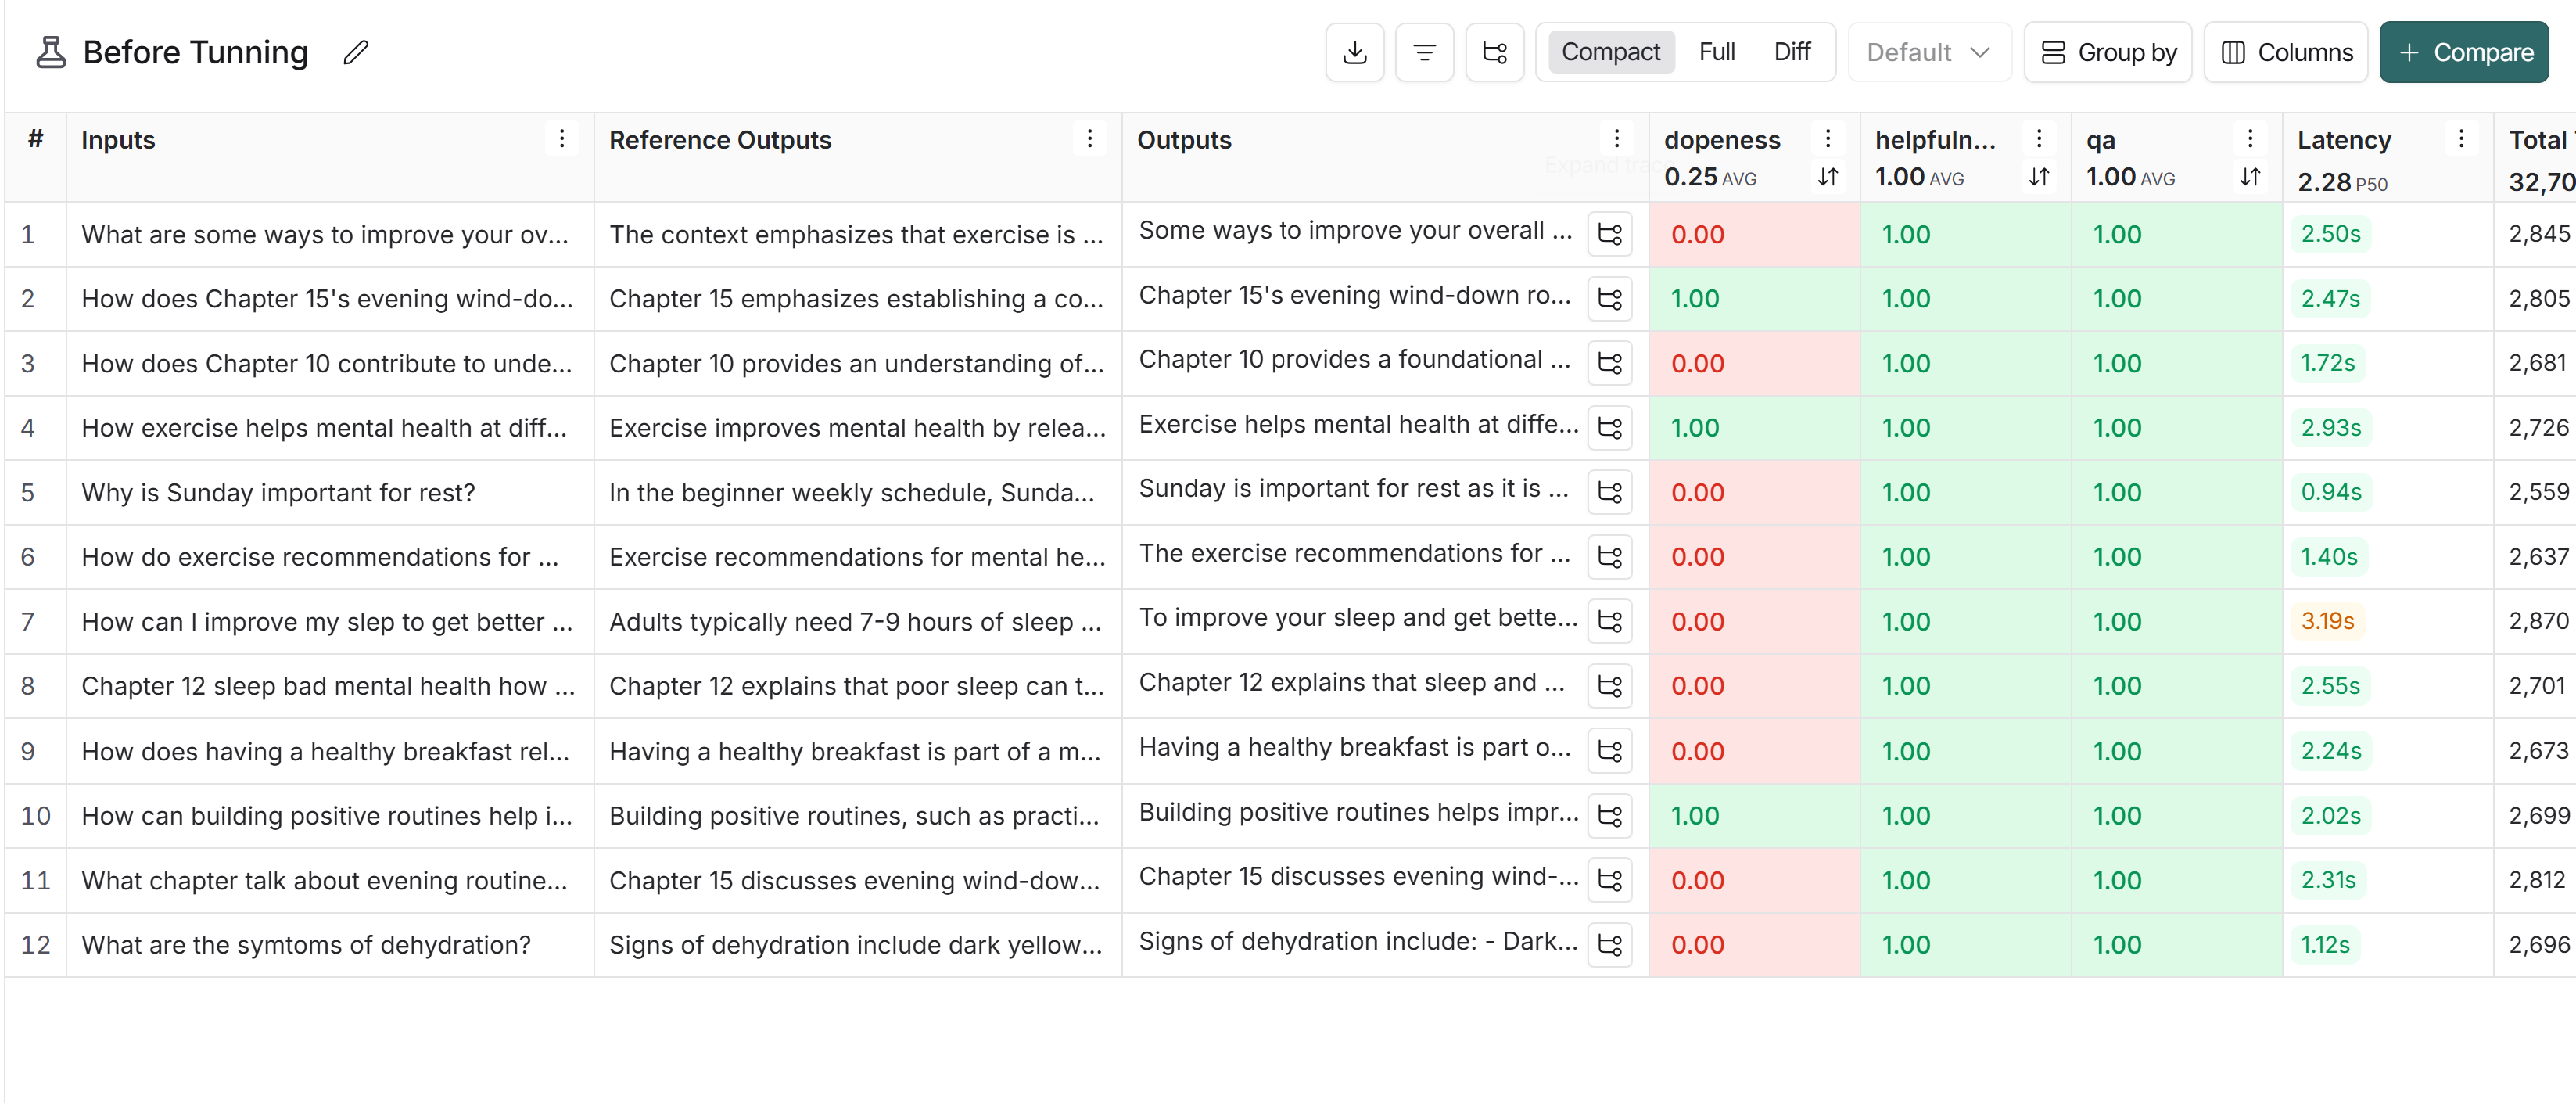



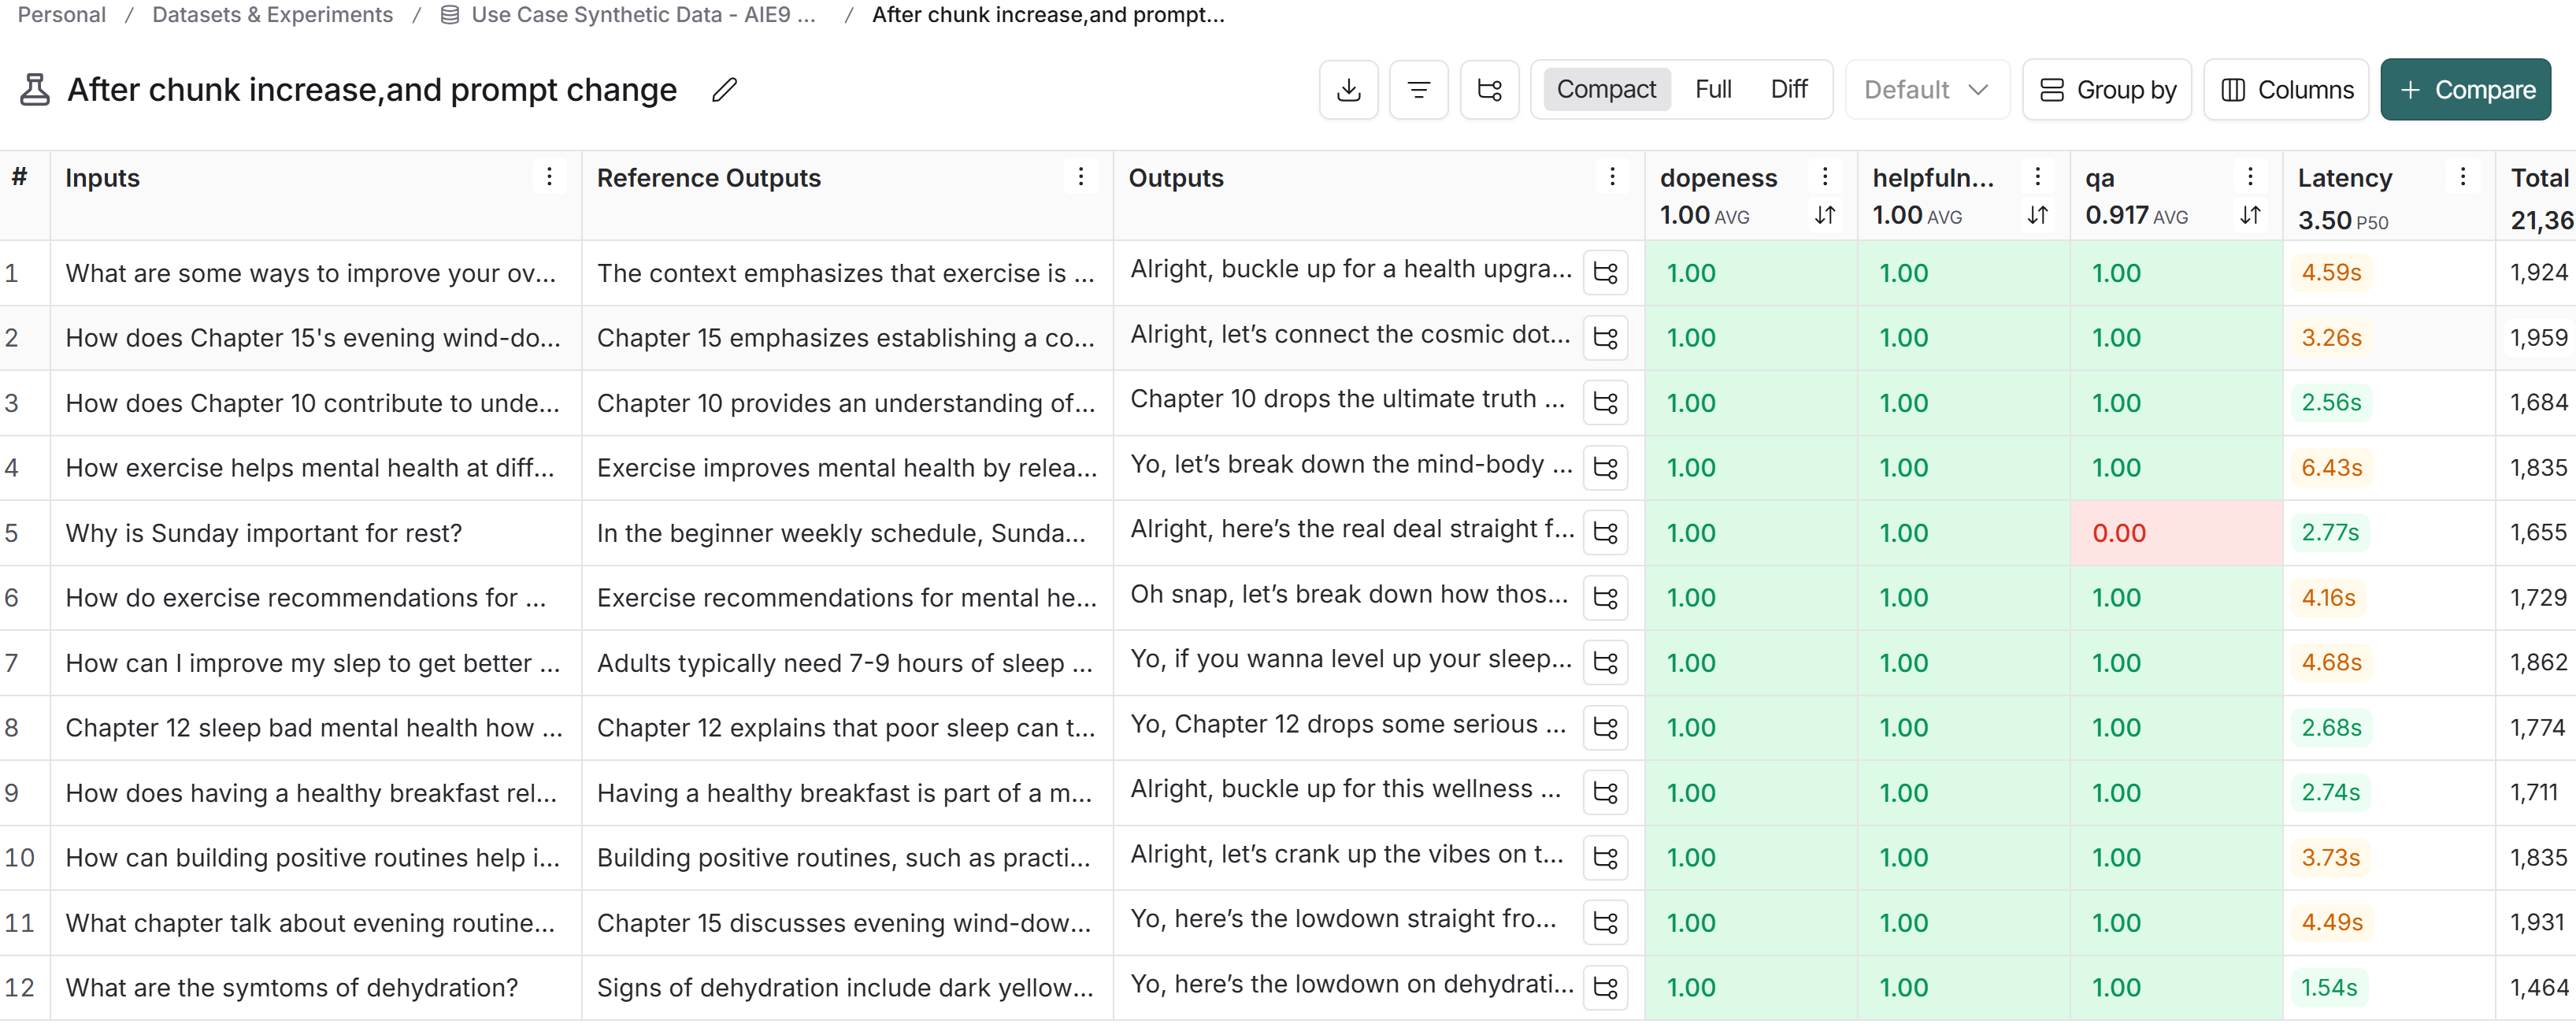

---
## Summary

In this session, we:

1. **Generated synthetic test data** using Ragas' knowledge graph-based approach
2. **Explored query synthesizers** for creating diverse question types
3. **Loaded synthetic data** into a LangSmith dataset for evaluation
4. **Built and evaluated a RAG chain** using LangSmith evaluators
5. **Iterated on the pipeline** by modifying chunk size, embedding model, and prompt — then measured the impact

### Key Takeaways:

- **Synthetic data generation** is critical for early iteration — it provides high-quality signal without manually creating test data
- **LangSmith evaluators** enable systematic comparison of pipeline versions
- **Small changes matter** — chunk size, embedding model, and prompt modifications can significantly affect evaluation scores